In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns 
import matplotlib.pyplot as plt
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')
print('Setup Complete')
%matplotlib inline
#impedir que os graficos sejam abertos em outras
#, facilitando organizacao (1(a))

/kaggle/input/datasets/imdevskp/corona-virus-report/covid_19_clean_complete.csv
/kaggle/input/datasets/imdevskp/corona-virus-report/country_wise_latest.csv
/kaggle/input/datasets/imdevskp/corona-virus-report/day_wise.csv
/kaggle/input/datasets/imdevskp/corona-virus-report/usa_county_wise.csv
/kaggle/input/datasets/imdevskp/corona-virus-report/worldometer_data.csv
/kaggle/input/datasets/imdevskp/corona-virus-report/full_grouped.csv
Setup Complete


In [2]:
covid_fp='/kaggle/input/datasets/imdevskp/corona-virus-report/covid_19_clean_complete.csv' 
#salvei o caminho do arquivo
covid_df=pd.read_csv(covid_fp) #criei uma df com esse arquivo
covid_df['Date']=pd.to_datetime(covid_df['Date'])
covid_df.head(50) #visualizacao

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.939110,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.153300,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.033900,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.506300,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.202700,17.873900,2020-01-22,0,0,0,0,Africa
5,NaN,Antigua and Barbuda,17.060800,-61.796400,2020-01-22,0,0,0,0,Americas
6,NaN,Argentina,-38.416100,-63.616700,2020-01-22,0,0,0,0,Americas
7,NaN,Armenia,40.069100,45.038200,2020-01-22,0,0,0,0,Europe
8,Australian Capital Territory,Australia,-35.473500,149.012400,2020-01-22,0,0,0,0,Western Pacific
9,New South Wales,Australia,-33.868800,151.209300,2020-01-22,0,0,0,0,Western Pacific


# **5.1 Graficos de Linha (Line Charts)**

In [4]:
regions=['Eastern Mediterranean','Americas','Europe'] 
#criada lista com regioes desejada para a resolucao
covid_df=covid_df.loc[covid_df['WHO Region'].isin(regions)]
#verifica se os dados da coluna "WHO Region" estao dentro da lista "regions"
#descartado os dados em que os paises nao correspondem aos continentes pedidos
infos=['WHO Region','Date','Deaths','Confirmed','Recovered','Active']
grpd_df=covid_df[infos]
grpd_df=grpd_df.groupby(['WHO Region','Date'])[['Deaths','Confirmed','Recovered','Active']].sum()
#colchetes duplos para evitar erro que identificava como "tuple"
#agrupado os datos de mesmo continente e mesmo dia (1(b))
grpd_df.tail(50)

Deaths  Confirmed  Recovered   Active
WHO Region Date                                             
Europe     2020-06-08  184916    2315091    1216139   914036
           2020-06-09  185772    2332325    1237390   909163
           2020-06-10  186577    2349587    1256602   906408
           2020-06-11  187151    2368943    1272296   909496
           2020-06-12  187797    2388550    1287964   912789
           2020-06-13  188346    2407860    1300647   918867
           2020-06-14  188668    2426076    1312062   925346
           2020-06-15  189051    2443902    1321220   933631
           2020-06-16  189832    2462281    1337579   934870
           2020-06-17  190585    2481193    1354893   935715
           2020-06-18  191203    2500695    1372042   937450
           2020-06-19  193007    2520961    1390755   937199
           2020-06-20  193523    2538802    1408166   937113
           2020-06-21  193818    2555397    1418962   942617
           2020-06-22  194113    2572065    1429004   948948
           2020-06-23  194742    2591290    1449049   947499
           2020-06-24  195247    2610439    1471123   944069
           2020-06-25  195713    2629250    1485474   948063
           2020-06-26  196379    2649366    1503617   949370
           2020-06-27  196813    2665549    1521639   947097
           2020-06-28  197111    2681253    1532922   951220
           2020-06-29  197472    2702012    1542279   962261
           2020-06-30  198043    2719021    1559158   961820
           2020-07-01  198660    2755944    1579255   978029
           2020-07-02  199157    2775329    1593684   982488
           2020-07-03  199709    2796333    1610300   986324
           2020-07-04  200113    2813781    1626572   987096
           2020-07-05  200423    2830582    1636186   993973
           2020-07-06  200844    2850929    1645999  1004086
           2020-07-07  201461    2868394    1664276  1002657
           2020-07-08  202001    2886022    1701224   982797
           2020-07-09  202530    2908712    1719472   986710
           2020-07-10  202983    2929712    1732722   994007
           2020-07-11  203505    2949166    1749673   995988
           2020-07-12  203908    2965384    1759085  1002391
           2020-07-13  204211    2989003    1770163  1014629
           2020-07-14  204708    3007333    1787389  1015236
           2020-07-15  205248    3029057    1808080  1015729
           2020-07-16  205716    3050612    1825253  1019643
           2020-07-17  206237    3073302    1840745  1026320
           2020-07-18  207289    3102225    1862549  1032387
           2020-07-19  207672    3122809    1876725  1038412
           2020-07-20  208181    3146816    1870500  1068135
           2020-07-21  208683    3168079    1892294  1067102
           2020-07-22  209185    3189394    1910928  1069281
           2020-07-23  209704    3216701    1933356  1073641
           2020-07-24  210193    3239712    1954150  1075369
           2020-07-25  210587    3259047    1970075  1078385
           2020-07-26  210840    3277229    1981991  1084398
           2020-07-27  211144    3299523    1993723  1094656

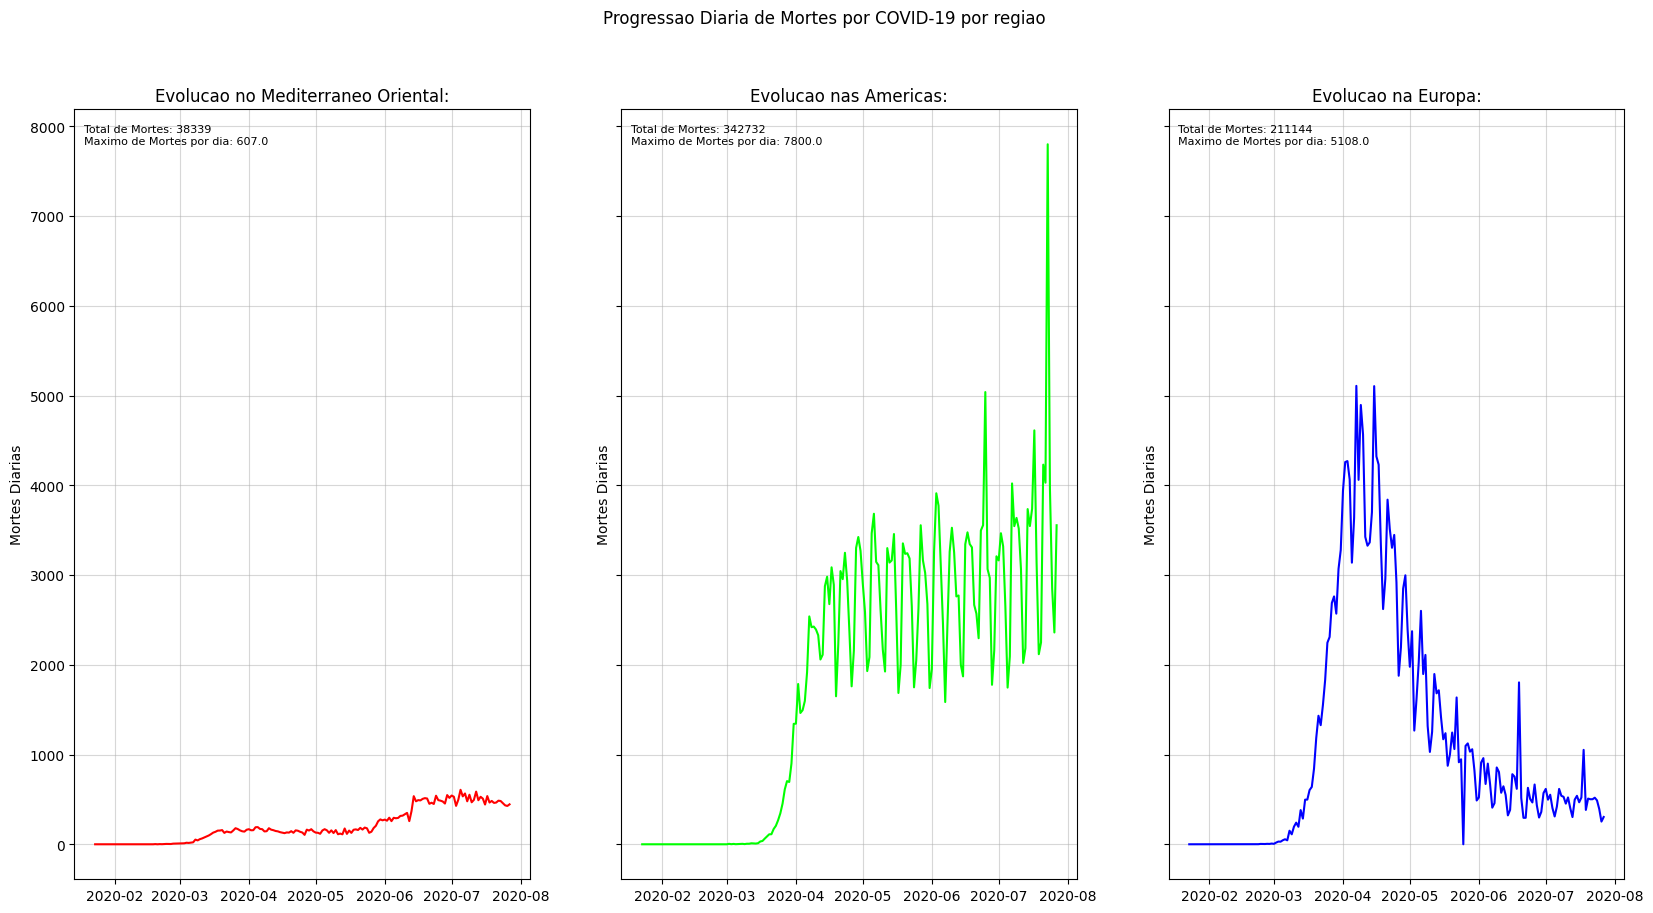

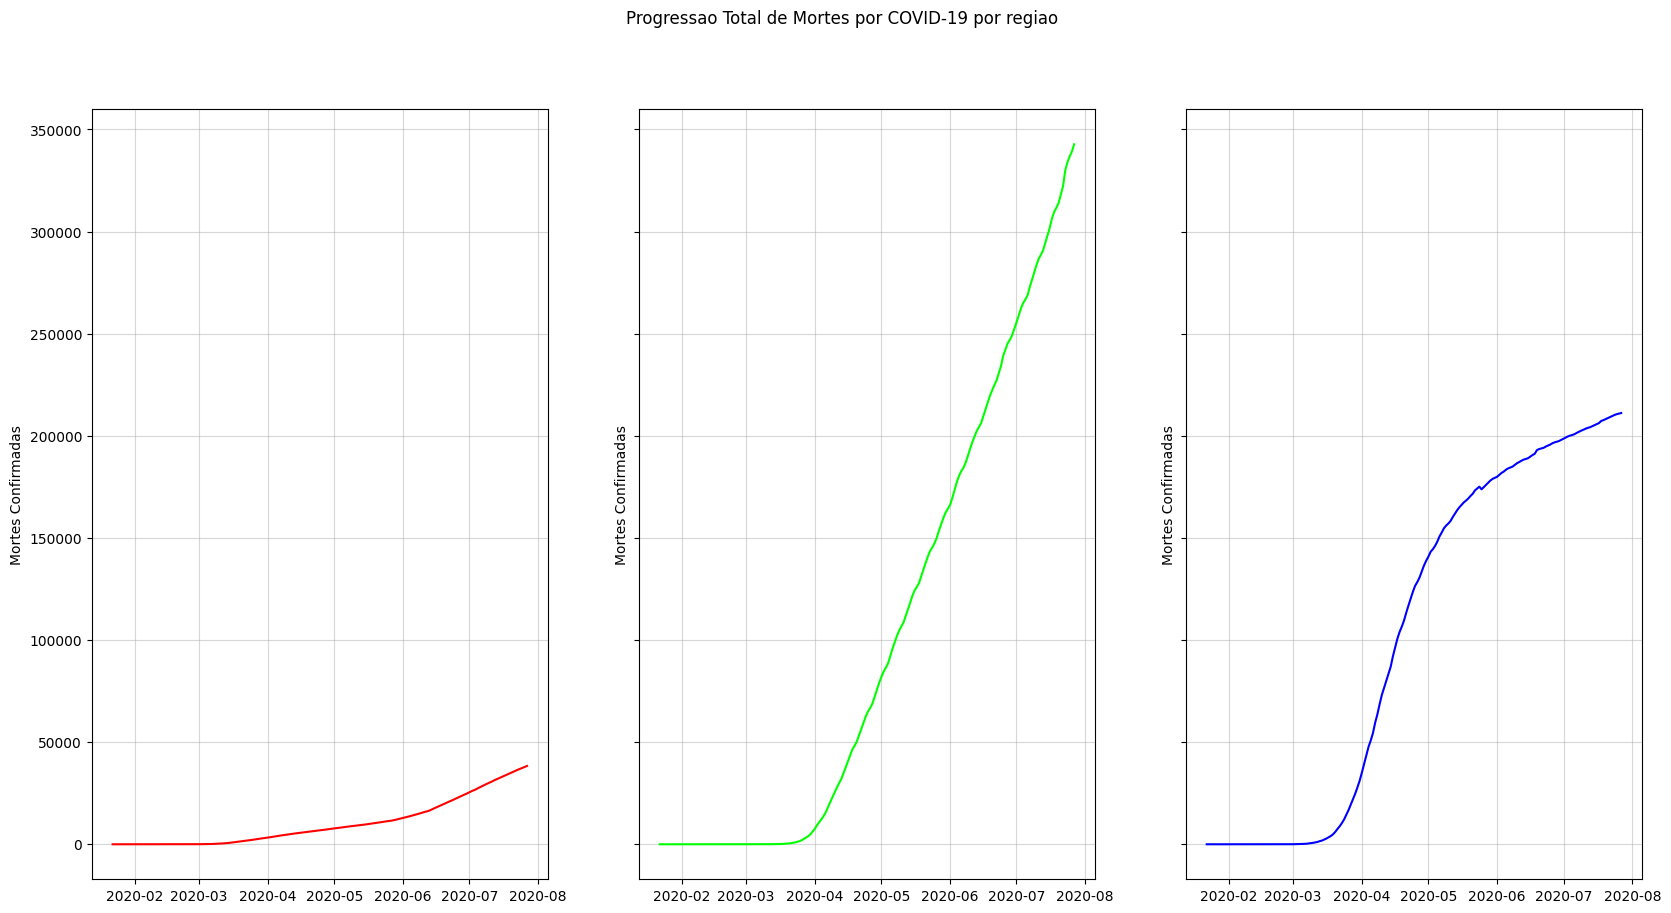

In [6]:
fig, axes=plt.subplots(1, 3, figsize=(20, 10), sharey=True)
#cria uma figura que mostrara todos os graficos em mesma linha
#a coloca todos eles em uma mesma escala, facilitando a comparacao
fig.suptitle('Progressao Diaria de Mortes por COVID-19 por regiao') 
#titulo principal para os tres graficos
colors=['#FF0000','#00FF00','#0000FF'] #codigo hex das tres cores primarias
titles=['Evolucao no Mediterraneo Oriental:',
       'Evolucao nas Americas:',
       'Evolucao na Europa:']
for i, region in enumerate(regions):
    ax=axes[i]
    ax.set_title(titles[i])
    ax.set_ylabel('Mortes Diarias') 
    #da nome ao eixo vertical
    ax.grid(True, alpha=0.5)
    #coloca uma grade e sua opacidade de 50%
    df_region=grpd_df.xs(region, level='WHO Region')
    #extrai temporariamente as informacoes de apenas uma regiao por vez
    daily_deaths=df_region['Deaths'].diff()
    daily_deaths=daily_deaths.clip(lower=0) 
    #como os dados das mortes sao cumulativos, nao faria sentido haver 
    #valores negativos, mas havia, indicando que possivelmente houve 
    #um ajuste dos dados das mortes que haviam sido superestimados
    #(final do mes 05 de 2020 na europa)
    max_daily_deaths=daily_deaths.max()
    total_deaths=df_region['Deaths'].iloc[-1]
    ax.plot(daily_deaths.index.get_level_values('Date'), daily_deaths.values, color=colors[i])
    text=f'Total de Mortes: {total_deaths} \nMaximo de Mortes por dia: {max_daily_deaths}'
    ax.text(0.02, 0.98, text,
            transform=ax.transAxes, 
            #torna as coordenadas serem relativas ao grafico
           fontsize=8,
           verticalalignment='top')



fig, axes=plt.subplots(1, 3, figsize=(20, 10), sharey=True)
#cria uma figura que mostrara todos os graficos em mesma linha
#coloca todos eles em uma mesma escala, facilitando a comparacao
fig.suptitle('Progressao Total de Mortes por COVID-19 por regiao') 
#titulo principal para os tres graficos
for i, region in enumerate(regions):
    ax=axes[i]
    ax.set_ylabel('Mortes Confirmadas') 
    #da nome ao eixo vertical
    ax.grid(True, alpha=0.5)
    #coloca uma grade e sua opacidade de 50%
    df_region=grpd_df.xs(region, level='WHO Region')
    #extrai temporariamente as informacoes de apenas uma regiao por vez
    deaths=df_region['Deaths']
    ax.plot(deaths.index.get_level_values('Date'), deaths.values, color=colors[i])


1: Americas, pois teve 342,732 mortes totais.

2: No Meditarraneo Oriental, A curva total de mortes cresceu cada vez mais, ate ter uma inclinacao levemente maior
entre junho e julho de 2020.

O mesmo acontece nas americas, com a curva crescendo cada vez mais.

Entretanto a europa tem um pico em meados de marco que acaba por volta de maio 

3: A taxa de crescimento da curva de mortes totais se comporta de forma diferente em cada uma das regioes.

Mediterraneo Oriental: crescimento positivo durante todo o periodo medido, mas devido a:
falta inicial de pcr; demografia; fechamento de aeroportos; rapida acao dos governos, esse numero ficou contido.

Americas: O principal motivo do virus nas americas terem causado um aumento constante ao numero total de mortes nas americas foi a magnetude do continente, que levou os paises mais relevantes a
serem sujeitos ao virus primeiro, entao isso dificulta a visualizacao das politicas de contencao pois elas foram aplicadas em momentos diferentes em cada pais.

Europa: Teve uma grande aumento inicial, devido a populacao envelhecida, terem sido a regiao que recebeu mais cedo o virus entre as regioes analisadas e a alta conectividade desse continente.
Entretanto, apos esse grande aumento inicial observa-se uma reducao drastica dos numero de mortes, resultado das politicas governamentais rigidas.

# **5.2 Graficos de Barras (Bar Charts)**

In [7]:
final_filepath='/kaggle/usr/lib/notebooks/mavicajo/atividade_cap_4/df_final.parquet'
#salvei o arquivo como parquet e fiz outro
#dataframe igual ao dataframe final da resolucao do 
#exercicio do capitulo 4
final=pd.read_parquet(final_filepath)
final
#chamado o dataframe para fins avaliativos

,Population,Deaths,Deaths per million
Continent,,,
South America,4.308076e+08,135506,314.539491
North America,2.568683e+08,59215,230.526685
Europe,6.794130e+08,155775,229.278789
Asia,3.020510e+09,85740,28.385939
Africa,1.215738e+09,17759,14.607591
Australia/Oceania,4.039107e+07,189,4.679252


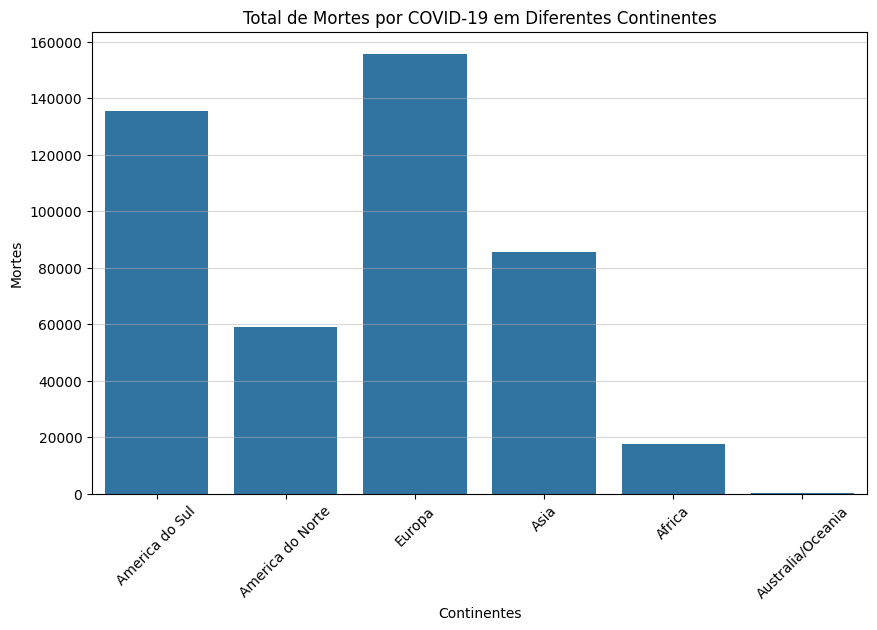

In [8]:
continentes=['America do Sul','America do Norte',
             'Europa','Asia',
             'Africa','Australia/Oceania']
plt.figure(figsize=(10, 6))
#ajuste de tamanho dos graficos (5.2(a))
plt.xticks(rotation=45) 
#rotaciona a identificacao do eixo horizontal
#para facilitar a leitura
plt.title('Total de Mortes por COVID-19 em Diferentes Continentes')
ax=sns.barplot(x=continentes, y=final['Deaths']) #(5.2(b))
ax.set_ylabel('Mortes')
ax.set_xlabel('Continentes')
plt.grid(axis='y', alpha=0.5)
#grid com 50% de opacidade
#colocado titulo, rotudos de eixo e
#grade para o grafico de barras (5.1(d))
plt.show()


**1: Os dois continentes com maior numero de mortes sao os a America do Sul e a Europa**


**2: A Oceania ( reprensentada pelos dados advindos da Australia) apresentou o menor numero de mortes**



**3: Como ja abordado, o continente europeu possui as populacoes mais velhas do mundo, grupo que e mais afetado pelo virus, alem disso, esse continente foi o primeiro a sofrer as consequencias do virus em larga escala devido a alta conectividade entre os paises europeus.
Ademais, a America do Sul foi o segundo continente mais afetado pois e um continente no geral, formado por paises emergentes e subdesenvolvidos, que sofrem de desigualdade social, gerando falta de infraestrutura de saude, alem disso, os paises sul-americanos tomaram medidas mais brandas que outros continentes para contem a doenca.
Outrossim, a Australia, bem como os outros paises menores que compoem a Oceania, sao mais isolados geograficamente e bloqueamento dos aeroportos, reduzindo drasticamente o controle de contato com individuos que estiveram em outros paises. Mas tambem a Australia e a Nova Zelandia ficaram conhecidos como os paises que promoveram as politicas mais rigidas, com lockdown mais rigido.**


# **5.3 Graficos de Dispersao (Scatter Plots)**

In [11]:
world_filepath='/kaggle/input/datasets/imdevskp/corona-virus-report/worldometer_data.csv'
world_df=pd.read_csv(world_filepath)
world_df

,Country/Region,Continent,Population,TotalCases,NewCases,TotalDeaths,NewDeaths,TotalRecovered,NewRecovered,ActiveCases,"Serious,Critical",Tot Cases/1M pop,Deaths/1M pop,TotalTests,Tests/1M pop,WHO Region
0,USA,North America,3.311981e+08,5032179,NaN,162804.0,NaN,2576668.0,NaN,2292707.0,18296.0,15194.0,492.0,63139605.0,190640.0,Americas
1,Brazil,South America,2.127107e+08,2917562,NaN,98644.0,NaN,2047660.0,NaN,771258.0,8318.0,13716.0,464.0,13206188.0,62085.0,Americas
2,India,Asia,1.381345e+09,2025409,NaN,41638.0,NaN,1377384.0,NaN,606387.0,8944.0,1466.0,30.0,22149351.0,16035.0,South-EastAsia
3,Russia,Europe,1.459409e+08,871894,NaN,14606.0,NaN,676357.0,NaN,180931.0,2300.0,5974.0,100.0,29716907.0,203623.0,Europe
4,South Africa,Africa,5.938157e+07,538184,NaN,9604.0,NaN,387316.0,NaN,141264.0,539.0,9063.0,162.0,3149807.0,53044.0,Africa
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204,Montserrat,North America,4.992000e+03,13,NaN,1.0,NaN,10.0,NaN,2.0,NaN,2604.0,200.0,61.0,12220.0,NaN
205,Caribbean Netherlands,North America,2.624700e+04,13,NaN,NaN,NaN,7.0,NaN,6.0,NaN,495.0,NaN,424.0,16154.0,NaN
206,Falkland Islands,South America,3.489000e+03,13,NaN,NaN,NaN,13.0,NaN,0.0,NaN,3726.0,NaN,1816.0,520493.0,NaN
207,Vatican City,Europe,8.010000e+02,12,NaN,NaN,NaN,12.0,NaN,0.0,NaN,14981.0,NaN,NaN,NaN,Europe


In [12]:
infos=['Country/Region','Continent','Population','Deaths/1M pop']
w_df=world_df[infos]
w_df
#seleciona apenas as informacoes importantes
#para a formacao do grafico

,Country/Region,Continent,Population,Deaths/1M pop
0,USA,North America,3.311981e+08,492.0
1,Brazil,South America,2.127107e+08,464.0
2,India,Asia,1.381345e+09,30.0
3,Russia,Europe,1.459409e+08,100.0
4,South Africa,Africa,5.938157e+07,162.0
...,...,...,...,...
204,Montserrat,North America,4.992000e+03,200.0
205,Caribbean Netherlands,North America,2.624700e+04,NaN
206,Falkland Islands,South America,3.489000e+03,NaN
207,Vatican City,Europe,8.010000e+02,NaN


In [13]:
order=w_df.groupby('Continent')['Deaths/1M pop'].mean().sort_values(ascending=False)
#criada um dataframe com os continentes ordenados por mortes por milhao e
#agrupados por continente de forma decrescente
top3=order.head(3).index.tolist()
#retirado os tres primeiros elementos desse dataframe
#e tranforma o indice em uma lista (5.3(a))
w_df=w_df[w_df['Continent'].isin(top3)]
#filtra o dataframe original com apenas os paises que
#pertencam aos tres continentes (5.3(b))
w_df


,Country/Region,Continent,Population,Deaths/1M pop
0,USA,North America,331198130.0,492.0
1,Brazil,South America,212710692.0,464.0
3,Russia,Europe,145940924.0,100.0
5,Mexico,North America,129066160.0,391.0
6,Peru,South America,33016319.0,619.0
...,...,...,...,...
203,Greenland,North America,56780.0,NaN
204,Montserrat,North America,4992.0,200.0
205,Caribbean Netherlands,North America,26247.0,NaN
206,Falkland Islands,South America,3489.0,NaN


In [15]:
top3


['South America', 'Europe', 'North America']

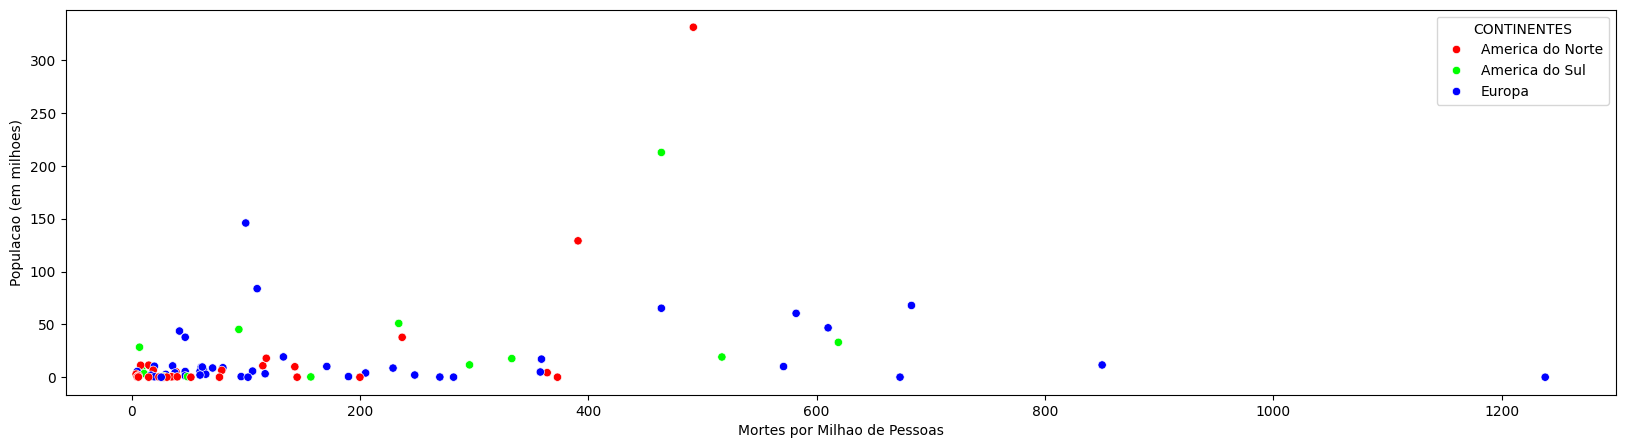

In [29]:
traducao = {'North America': 'America do Norte',
            'South America': 'America do Sul',
            'Europe': 'Europa'}
#criado dicionario com as palavrasa traduzidas
w_df2 = w_df.copy()
w_df2['Continent_pt'] = w_df2['Continent'].map(traducao)
#criada nova coluna com os nomes em português
plt.figure(figsize=(20,5))
ax=sns.scatterplot(x = w_df2['Deaths/1M pop'],
                   y = w_df2['Population']/10**6,
                  hue = w_df2['Continent_pt'],
                   hue_order = ['America do Norte', 'America do Sul', 'Europa'],
                  palette = colors)
#define uma cor diferente para cada continente (5.3(c))
ax.set_xlabel('Mortes por Milhao de Pessoas')
ax.set_ylabel('Populacao (em milhoes)')
plt.legend(title = 'CONTINENTES')
plt.show()

**1: Existe uma concentracao de paises no canto inferior direito do grafico, correspondendo aos paises com menos 30 milhoes de habitantes e menos de 100 mortos por milhao**


**2:Nao existe uma relacao clara a ser observada entre tamanho populacional e morte por milhao de pessoas por covid-19**


**3:Nao existe relacao perceptivel entre os dados que foram relacionados como os eixos do grafico.**

# **Mapa de Calor de Correlacao (Correlation Heatmap)**

In [25]:
world_df
#data_frame cirado anteriormente contendo as informacoes
#dos worldometer
infos=['Population','TotalCases',
       'NewCases', 'TotalDeaths',
       'NewDeaths', 'TotalRecovered',
       'NewRecovered', 'ActiveCases',
       'Serious,Critical', 'Tot Cases/1M pop',
       'Deaths/1M pop', 'TotalTests', 'Tests/1M pop']
df=world_df[infos]
data=df.corr()
#montada uma "matriz" de correlacao entre os dados
data

,Population,TotalCases,NewCases,TotalDeaths,NewDeaths,TotalRecovered,NewRecovered,ActiveCases,"Serious,Critical",Tot Cases/1M pop,Deaths/1M pop,TotalTests,Tests/1M pop
Population,1.000000,0.546158,0.889610,0.431072,0.910836,0.590239,0.854194,0.459124,0.595379,-0.009337,0.025686,0.497937,-0.075129
TotalCases,0.546158,1.000000,0.999459,0.938622,0.998062,0.985764,0.998258,0.969423,0.967270,0.252627,0.280476,0.891001,0.029141
NewCases,0.889610,0.999459,1.000000,0.991894,0.995554,0.991416,0.999636,0.935500,0.985526,0.321203,0.842468,0.214572,-0.669339
TotalDeaths,0.431072,0.938622,0.991894,1.000000,0.999507,0.935410,0.988362,0.927625,0.906627,0.237206,0.425186,0.850304,0.053870
NewDeaths,0.910836,0.998062,0.995554,0.999507,1.000000,0.998935,0.992651,0.888717,0.997112,0.046499,0.751519,0.039460,-0.803470
TotalRecovered,0.590239,0.985764,0.991416,0.935410,0.998935,1.000000,0.986012,0.914566,0.949628,0.268483,0.296443,0.870113,0.022027
NewRecovered,0.854194,0.998258,0.999636,0.988362,0.992651,0.986012,1.000000,0.937663,0.980595,0.167036,0.825828,-0.081745,-0.869608
ActiveCases,0.459124,0.969423,0.935500,0.927625,0.888717,0.914566,0.937663,1.000000,0.945943,0.212899,0.255001,0.911488,0.028963
"Serious,Critical",0.595379,0.967270,0.985526,0.906627,0.997112,0.949628,0.980595,0.945943,1.000000,0.209668,0.271842,0.859526,0.020649
Tot Cases/1M pop,-0.009337,0.252627,0.321203,0.237206,0.046499,0.268483,0.167036,0.212899,0.209668,1.000000,0.502134,0.194120,0.302728


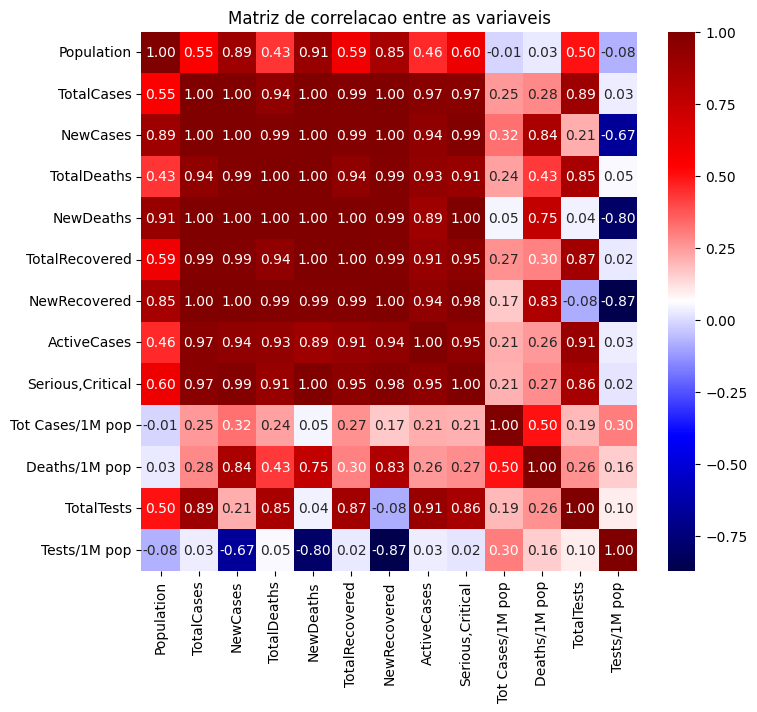

In [26]:
plt.figure(figsize=(8, 7))
ax=sns.heatmap(data, 
               annot=True,
#permite que os valores numericos sejam visualizados
               cmap='seismic',
#padrao de cores que facilita a visualizacao
              fmt='.2f')
#formatacao para impedir que os numeros fiquem
#uns sobre os outros
plt.title('Matriz de correlacao entre as variaveis')
plt.show()

**Variaveis escolhidas para serem interpretadas ("Population" e "Tests/1M pop").**

**Population: a quantidade da populacao do pais, quando comparada a variaveis de valor absoluto, como "TotalCases", "NewCases", "TotalDeaths", "NewDeaths", "TotalRecovered", "NewRecovered", "ActiveCases", "Serious,Critical", "TotalTests", possui correlacao direta elevada, indicando que ,por exemplo, quanto mais pessoas tem em um pais, mais casos de covid-19 ocorrerao la, oque esta de acordo com o senso comum.**
**Ja a valores relativos, como "Tot Cases/1M pop", "Deaths/1M pop", "Tests/1M pop" apresenta quase nenhuma relacao linear, oque significa que a populacao nao deteermina o quao alto sera o numero de pessoas que contrairam a doenca, novamente estando na mesma linha do senso comum.**


**Tests/1m pop: a quantidade de testes de covid-19 apresenta relacao linear altissima quando analisada entre variaveis como "NewCases", "NewDeaths", "NewRecovered", indicando que, por exemplo, quando mais pessoas fazem testes de covid mais pessoas possuem o virus (pois o jeito de verificar a presenca do virus no corpo seria fazendo o teste), indo de acordo com a logica.**
**Alem disso, nao apresenta relacao perceptivel entre variaveis absolutas como "TotalCases", "TotalRecovered", "ActiveCases", "Serious,Critical", "TotalTests"**
